# Habitat suitability under climate change

Our changing climate is changing where plant species can live,
and conservation and restoration practices will need to take
this into
account.

In this coding challenge, you will create a habitat suitability model
for a terrestrial plant species of your choice that lives in the contiguous United States
(CONUS). We have this limitation because the downscaled climate data we
suggest, the [MACAv2 dataset](https://www.climatologylab.org/maca.html),
is only available in the CONUS – if you find other downscaled climate
data at an appropriate resolution, you are welcome to choose a different
study area. If you don’t have anything in mind, you can take a look at
[*Sorghastrum nutans*](https://www.gbif.org/species/2704414), a grass native to North America. In the past 50
years, its range has moved
northward.

Your suitability assessment will be based on combining multiple data
layers related to soil, topography, and climate, then applying a fuzzy logic model across the different data layers to generate habitat suitability maps. 

You will need to create a **modular, reproducible, workflow** using functions and loops.
To do this effectively, we recommend planning your code out in advance
using a technique such as a pseudocode outline or a flow diagram. We
recommend breaking each of the blocks below out into multiple steps. It
is unnecessary to write a step for every line of code unless you find
that useful. As a rule of thumb, aim for steps that cover the major
structures of your code in 2-5 line chunks.

In [1]:
# To create reproducible file paths
import os
from pathlib import Path
import pathlib

In [2]:
# To use APIs
import requests

# To download the GBIF data
from getpass import getpass
import pygbif.occurrences as occ
import pygbif.species as species

In [3]:
# For unzipping folders
import time
import zipfile

In [4]:
# To work with different types of data
import geopandas as gpd # To make GeoDataFrames/work with vector data
from glob import glob # To combine data arrays
import numpy as np # To work with arrays
import pandas as pd # To work with dataframes
import rioxarray as rxr # To work with raster data

In [5]:
import rioxarray.merge as rxrm # To merge raster data
from shapely.geometry import MultiPolygon, Polygon # To handle invalid geometries
import xrspatial # To handle spatial data

In [6]:
# For visualization and interactive plotting
import geoviews as gv
import holoviews as hv
import hvplot.pandas
import hvplot.xarray

In [7]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 

In [8]:
from math import floor, ceil

In [9]:
# Import the below libraries:
# To create reproducible file paths
import os
from pathlib import Path
import pathlib

# To use APIs
import earthaccess # For logging into NASA Earth Access
import requests

# To download the GBIF data
from getpass import getpass
import pygbif.occurrences as occ
import pygbif.species as species

# For unzipping folders
import time
import zipfile

# To work with different types of data
import geopandas as gpd # To make GeoDataFrames/work with vector data
from glob import glob # To combine data arrays
from math import floor, ceil # For dealing with integers
import numpy as np # To work with arrays
import pandas as pd # To work with dataframes
import rioxarray as rxr # To work with raster data
import rioxarray.merge as rxrm # To merge raster data
from shapely.geometry import MultiPolygon, Polygon # To handle invalid geometries
import xarray as xr # To use xarray datasets
import xrspatial # To handle spatial data

# For visualization and interactive plotting
import geoviews as gv
import holoviews as hv
import hvplot.pandas
import hvplot.xarray
import matplotlib.gridspec as gridspec 
import matplotlib.pyplot as plt

In [10]:
# Create a designated folder for the repository data
data_dir = os.path.join(
    pathlib.Path.home(),
    # In the earth-analytics data folder
    'earth-analytics',
    'data',
    # Specify the destination as inside the "spring-03-habitat-suitability-climate-change-_____" repository
    'spring-03-habitat-suitability-climate-change-Livian-Von-Dran',
    'redwood_habitat_suitability'
)

# Create the directory
os.makedirs(data_dir, exist_ok=True)

## STEP 1: Study overview

Before you begin coding, you will need to design your study.

### Step 1a: Select a species
Select the terrestrial plant species you want to study, and research its habitat parameters in scientific studies or other reliable sources. Individual studies may not have the breadth needed for this purpose, so take a look at reviews or overviews of the data. Do **not** just look at an AI-generated summary! In the US, the National Resource Conservation Service can have helpful fact sheets about different species. University Extension programs are also good resources for summaries.</p>
<p>Based on your research, select soil, topographic, and climate variables that you can use to determine if a particular location and time period is a suitable habitat for your species.</p></div></div>

**Reflect and respond**: 
Write a description of your species. What habitat is it found in? What is its geographic range? What, if any, are conservation threats to the species? What data will shed the most light on habitat suitability for this species? 

What core scientific question do you hope to answer about potential future changes in habitat suitability? Don't forget to cite your sources!

Your response here:

The species I have chosen is known by several names, chief among them being the California redwood or coast redwood (*Sequoia sempervirens*). Belonging to the Sequoioideae, this species is among the largest tree species ever documented, making it a desirable target for logging operations. Historically, redwood forests were restricted to a 900 kilometer belt along the Coast Range that spanned between central California and southern Oregon (Lorimer et al., 2009), but logging has removed 95% of the existing old-growth forests (Save the Redwoods League, 2018). Remaining old-growth redwood forests continue to be threatened by deforestation, invasive species, and increasingly destructive wildfires (Lorimer et al., 2009). Given that a previous project measured fog occurrence to support redwood habitat assessments, such data may be useful to determine habitat suitability for the California redwood (Wernet et al., 2020). For my core scientific question, I wish to address how altered temperature and precipitation will affect the habitat suitability of the already limited Calfiornia redwood range.

References

Burns, E. E., Campbell, R., & Cowan, P. D. (2018). *State of Redwoods Conservation Report*. https://www.savetheredwoods.org/wp-content/uploads/State-of-Redwoods-Conservation-Report-Final-web.pdf

Lorimer, C. G., Porter, D. J., Madej, M. A., Stuart, J. D., Veirs, S. D., Norman, S. P., O’Hara, K. L., & Libby, W. J. (2009). Presettlement and modern disturbance regimes in coast redwood forests: Implications for the conservation of old-growth stands. *Forest Ecology and Management*, *258*(7), 1038–1054. https://doi.org/10.1016/j.foreco.2009.07.008

Werner, Z., Berger, A., Winter, A., Choi, C. T. H., Evangelista, P., Jarnevich, C., Vorster, T., Woodward, B., & Young N. (2020). *California & Oregon Ecological Forecasting: Detecting and Forecasting Fog Occurrence, Frequency, and Change to Support Coast Redwood (Sequoia sempervirens) Habitat Assessments*. https://ntrs.nasa.gov/api/citations/20205011382/downloads/2020Fall_CO_California%26OregonEco_ProjectSummary_FD-final.docx.pdf


In [11]:
# Create a directory for the GBIF data
gbif_dir = os.path.join(data_dir, 'gbif_redwood_dir')

In [12]:
# Permanently log into GBIF
# Do not reset credentials to avoid repeated login requests
reset_credentials = False

# Request and store username
if (not ('GBIF_USER'  in os.environ)) or reset_credentials:
    os.environ['GBIF_USER'] = input('GBIF username:')

# Request and store password
if (not ('GBIF_PWD'  in os.environ)) or reset_credentials:
    os.environ['GBIF_PWD'] = getpass('GBIF password:')
    
# Request and store email address
if (not ('GBIF_EMAIL'  in os.environ)) or reset_credentials:
    os.environ['GBIF_EMAIL'] = input('GBIF email:')

In [13]:
# Check that the login attempt was successful
'GBIF_PWD' in os.environ

True

In [14]:
# Set the species name
species_name = "Sequoia sempervirens"

# Pull the species info from GBIF
species_info = species.name_lookup(species_name, rank = 'Species')

# Grab the first result and print it
first_result = species_info['results'][0]
first_result

{'key': 127697664,
 'datasetKey': '91fecd78-0986-4713-9c36-77532846ee25',
 'nubKey': 2683909,
 'parentKey': 127697689,
 'parent': 'Sequoia',
 'kingdom': 'Plantae',
 'phylum': 'Pinophyta',
 'order': 'Pinales',
 'family': 'Taxodiaceae',
 'genus': 'Sequoia',
 'species': 'Sequoia sempervirens',
 'kingdomKey': 305476039,
 'phylumKey': 305476125,
 'classKey': 305476126,
 'orderKey': 305476127,
 'familyKey': 305476136,
 'genusKey': 127697689,
 'speciesKey': 127697664,
 'scientificName': 'Sequoia sempervirens (Lamb.) Endl.',
 'canonicalName': 'Sequoia sempervirens',
 'authorship': '(Lamb.) Endl.',
 'publishedIn': 'Syn. Conif. 198. 1847',
 'accordingTo': 'VV.AA. Flora of North America. Oxford University Press. New York and Oxford',
 'nameType': 'SCIENTIFIC',
 'taxonomicStatus': 'ACCEPTED',
 'rank': 'SPECIES',
 'origin': 'SOURCE',
 'numDescendants': 0,
 'numOccurrences': 0,
 'taxonID': '0ECE391C-C401-4F9E-B859-07B71272E97F',
 'habitats': [],
 'nomenclaturalStatus': [],
 'threatStatuses': [],
 'd

In [15]:
# Get the species key
species_key = first_result['nubKey']

# Check what the species key is
first_result['species'], species_key

('Sequoia sempervirens', 2683909)

In [16]:
# Assign the species key found in the previous inquiry
species_key = 2683909

In [17]:
# Create the file path
gbif_pattern = os.path.join(gbif_dir, '*.csv')

# Create a function to download the redwood occurrence data
if not glob(gbif_pattern):
    # Submit the query to GBIF
    gbif_query = occ.download([
        f"speciesKey = {species_key}",
        "hasCoordinate = True",
    ])
    # Only download the data once
    if not 'GBIF_DOWNLOAD_KEY' in os.environ:
        os.environ['GBIF_DOWNLOAD_KEY'] = gbif_query[0]
        download_key = os.environ['GBIF_DOWNLOAD_KEY']
        time.sleep(5)
    # Download the data
    download_info = occ.download_get(
        os.environ['GBIF_DOWNLOAD_KEY'],
        path = data_dir
    )
    # Unzip the file
    with zipfile.ZipFile(download_info['path']) as download_zip:
        download_zip.extractall(path = gbif_dir)

# Locate the CSV file path
gbif_path = glob(gbif_pattern)[0]

In [18]:
# Look at the download information
occ.download_meta("0043121-260226173443078") # Input the download key to view the information

{'key': '0043121-260226173443078',
 'doi': '10.15468/dl.5bexbs',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '2683909',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-03-17T03:24:42.070+00:00',
 'modified': '2026-03-17T03:26:35.455+00:00',
 'eraseAfter': '2026-09-17T03:24:41.922+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0043121-260226173443078.zip',
 'size': 1453237,
 'totalRecords': 21578,
 'numberDatasets': 288}

In [19]:
# Read the CSV
gbif_df = pd.read_csv(
    gbif_path,
    delimiter = '\t'
)

# Check the dataframe
gbif_df

C:\Users\livth\AppData\Local\Temp\ipykernel_1436\257810896.py:2: DtypeWarning: Columns (0: infraspecificEpithet) have mixed types. Specify dtype option on import or set low_memory=False.
  gbif_df = pd.read_csv(


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,986394934,2429287b-ef65-4cfd-afcc-11cc3ba95cca,urn:catalog:ALTA-VP:132704,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,"Deyholos, M. K.",NaN,CC0_1_0,University of Alberta Museums,"Deyholos, M. K.",NaN,NaN,2026-02-27T16:46:54.642Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;OCCURRENCE_STATUS...
1,930742189,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Maurice J. Kaufmann,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:10.617Z,StillImage,NaN
2,930742172,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Maurice J. Kaufmann,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:12.158Z,StillImage,NaN
3,930742166,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Maurice J. Kaufmann,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:11.647Z,StillImage,NaN
4,930741653,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-baskauf/41...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Steven J. Baskauf,2005-07-28T00:00:00,CC0_1_0,NaN,Steven J. Baskauf,NaN,native,2026-01-30T23:26:10.994Z,StillImage,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21595,1024187447,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/777058,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Ken-ichi Ueda,2014-07-10T07:56:43,CC0_1_0,Ken-ichi Ueda,Ken-ichi Ueda,NaN,NaN,2026-03-12T02:58:59Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
21596,1024186865,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/775641,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,Chris Cook,2014-07-09T04:59:15,CC_BY_NC_4_0,Chris Cook,Chris Cook,NaN,NaN,2026-03-12T05:31:53.095Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
21597,1024184572,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/769678,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,JJ Johnson,2014-07-05T03:18:09,CC_BY_NC_4_0,JJ Johnson,JJ Johnson,NaN,NaN,2026-03-12T07:26:02.519Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
21598,1024184101,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/767949,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,James Maughn,2014-07-04T06:20:45,CC_BY_NC_4_0,James Maughn,James Maughn,NaN,NaN,2026-03-12T05:32:12.555Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...


In [20]:
# Look at the columns
gbif_df.columns

Index(['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class',
       'order', 'family', 'genus', 'species', 'infraspecificEpithet',
       'taxonRank', 'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='str')

In [21]:
# Convert the dataframe into a geodataframe (GDF)
gbif_gdf = (
    gpd.GeoDataFrame(
        gbif_df,
        # Add geometry columns to convert to a GDF
        geometry = gpd.points_from_xy(
            gbif_df.decimalLongitude,
            gbif_df.decimalLatitude
        ),
        crs = 'EPSG:4326'
    )
)

# Display the GDF data
gbif_gdf

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue,geometry
0,986394934,2429287b-ef65-4cfd-afcc-11cc3ba95cca,urn:catalog:ALTA-VP:132704,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,NaN,CC0_1_0,University of Alberta Museums,"Deyholos, M. K.",NaN,NaN,2026-02-27T16:46:54.642Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;OCCURRENCE_STATUS...,POINT (-113.51667 53.51667)
1,930742189,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:10.617Z,StillImage,NaN,POINT (-124.0411 41.3232)
2,930742172,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:12.158Z,StillImage,NaN,POINT (-124.0411 41.3232)
3,930742166,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-kaufmannm/...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,1977-01-01T00:00:00,CC0_1_0,NaN,Maurice J. Kaufmann,NaN,native,2026-01-30T23:26:11.647Z,StillImage,NaN,POINT (-124.0411 41.3232)
4,930741653,0096dfc0-9925-47ef-9700-9b77814295f1,http://bioimages.vanderbilt.edu/ind-baskauf/41...,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,2005-07-28T00:00:00,CC0_1_0,NaN,Steven J. Baskauf,NaN,native,2026-01-30T23:26:10.994Z,StillImage,NaN,POINT (-124.087 41.79557)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21595,1024187447,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/777058,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,2014-07-10T07:56:43,CC0_1_0,Ken-ichi Ueda,Ken-ichi Ueda,NaN,NaN,2026-03-12T02:58:59Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-123.8809 39.84946)
21596,1024186865,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/775641,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,2014-07-09T04:59:15,CC_BY_NC_4_0,Chris Cook,Chris Cook,NaN,NaN,2026-03-12T05:31:53.095Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-123.71906 39.85849)
21597,1024184572,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/769678,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,2014-07-05T03:18:09,CC_BY_NC_4_0,JJ Johnson,JJ Johnson,NaN,NaN,2026-03-12T07:26:02.519Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-122.29738 37.27652)
21598,1024184101,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/767949,Plantae,Tracheophyta,Pinopsida,Pinales,Cupressaceae,Sequoia,Sequoia sempervirens,...,2014-07-04T06:20:45,CC_BY_NC_4_0,James Maughn,James Maughn,NaN,NaN,2026-03-12T05:32:12.555Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-121.92512 36.99144)


In [22]:
# Create an interactive plot of the GDIF redwood observation data
gbif_gdf.hvplot(
    geo = True,
    tiles = 'EsriImagery',
    title = 'Redwood Observations on GDIF',
    # Avoid using a fill color, but select a line color of your choice
    fill_color = None,
    line_color = 'purple',
)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]

### Step 1b: Select study sites
Based on your research and/or range maps you find online, select at least 2 sites where your species occurs. These could be national parks, national forests, national grasslands or other protected areas, or some other area you're interested in. You can access protected area polygons from the [US Geological Survey's Protected Area Database](https://www.usgs.gov/programs/gap-analysis-project/science/pad-us-data-overview), [national grassland units](https://data.fs.usda.gov/geodata/edw/edw_resources/shp/S_USA.NationalGrassland.zip), etc.

When selecting your sites, you might want to look for places that are marginally habitable for this species, since those locations will be most likely to show changes due to climate.

Generate a site map for each location.

In [23]:
# Create a directory for the park sites
site_dir = Path(data_dir) / "redwood_sites"
site_dir.mkdir(parents=True, exist_ok=True)

# Create a path to access the zip file
"""Most California redwoods are found in protected state and National Parks in California, so the database of choice is  
the California Protected Areas Database (CPAD). As of 2025, the name of the zip file is "cpad_release_2025b.zip,"
downloadable at 
https://data.cnra.ca.gov/dataset/0ae3cd9f-0612-4572-8862-9e9a1c41e659/resource/27323846-4000-42a2-85b3-93ae40edeff9/download/cpad_release_2025b.zip."""
zip_path = site_dir / "cpad_release_2025b.zip"

# Print the zip file path
print(zip_path)

C:\Users\livth\earth-analytics\data\spring-03-habitat-suitability-climate-change-Livian-Von-Dran\redwood_habitat_suitability\redwood_sites\cpad_release_2025b.zip


In [25]:
# Establish the redwood site URL for the download
redwood_url = "https://data.cnra.ca.gov/dataset/0ae3cd9f-0612-4572-8862-9e9a1c41e659/resource/27323846-4000-42a2-85b3-93ae40edeff9/download/cpad_release_2025b.zip"

# Download the data only once
if not zip_path.exists():
     with requests.get(redwood_url, stream=True) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

# Extract the files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(site_dir)

OSError: [Errno 22] Invalid argument: 'C:\\Users\\livth\\earth-analytics\\data\\spring-03-habitat-suitability-climate-change-Livian-Von-Dran\\redwood_habitat_suitability\\redwood_sites\\CPAD_Release_2025b\\CPAD_2025b_Holdings\\CPAD_2025b_Holdings.shp'

In [26]:
# Define a path to the desired shapefile
"""Individual state and National Parks will be distinct layers in the units shapefile."""
redwood_shp = r"C:\Users\livth\earth-analytics\data\spring-03-habitat-suitability-climate-change-Livian-Von-Dran\redwood_habitat_suitability\redwood_sites\CPAD_Release_2025b\CPAD_2025b_Units\CPAD_2025b_Units.shp"

# Display the columns in the shapefile
cpad_units = gpd.read_file(redwood_shp)
cpad_units.head()

,ACCESS_TYP,UNIT_ID,UNIT_NAME,SUID_NMA,AGNCY_ID,AGNCY_NAME,AGNCY_LEV,AGNCY_TYP,AGNCY_WEB,LAYER,...,COUNTY,ACRES,LABEL_NAME,YR_EST,GAP1_acres,GAP2_acres,GAP3_acres,GAP4_acres,GAP_tot_ac,geometry
0,Open Access,2,Shelter Island Shoreline Park,25388,2133,San Diego Unified Port District,Special District,Port/Harbor District,https://www.portofsandiego.org/,Special District,...,San Diego,22.902550,Shelter Island Shoreline Park,0,0.0,0.0,0.0,22.00,22.00,"MULTIPOLYGON (((260927.589 -584356.149, 260931..."
1,Open Access,3,Harbor Island Park,19664,2133,San Diego Unified Port District,Special District,Port/Harbor District,https://www.portofsandiego.org/,Special District,...,San Diego,9.613719,Harbor Island Park,0,0.0,0.0,0.0,9.00,9.00,"MULTIPOLYGON (((263770.523 -583641.7, 263772.0..."
2,Open Access,4,Spanish Landing Park,25712,2133,San Diego Unified Port District,Special District,Port/Harbor District,https://www.portofsandiego.org/,Special District,...,San Diego,15.982519,Spanish Landing Park,0,0.0,0.0,0.0,15.00,15.00,"POLYGON ((262893.432 -583193.588, 262891.94 -5..."
3,Open Access,5,Zena Mini-Park,27862,1297,"San Diego, City of",City,City Agency,https://www.sandiego.gov/park-and-recreation/,City,...,San Diego,0.063378,Zena Mini-Park,0,0.0,0.0,0.0,0.06,0.06,"POLYGON ((276101.312 -580807.028, 276099.203 -..."
4,Open Access,6,Wabash Neighborhood Park,30119,1297,"San Diego, City of",City,City Agency,https://www.sandiego.gov/park-and-recreation/,City,...,San Diego,0.130749,Wabash Neighborhood Park,0,0.0,0.0,0.0,0.13,0.13,"POLYGON ((270177.644 -580664.636, 270166.537 -..."


In [27]:
# Filter by "UNIT_NAME" for Redwood National Park and display the results
rnp_gdf = cpad_units[cpad_units["UNIT_NAME"] == "Redwood National Park"] 
rnp_gdf

,ACCESS_TYP,UNIT_ID,UNIT_NAME,SUID_NMA,AGNCY_ID,AGNCY_NAME,AGNCY_LEV,AGNCY_TYP,AGNCY_WEB,LAYER,...,COUNTY,ACRES,LABEL_NAME,YR_EST,GAP1_acres,GAP2_acres,GAP3_acres,GAP4_acres,GAP_tot_ac,geometry
8726,Open Access,21584,Redwood National Park,14271,108,United States National Park Service,Federal,Federal Agency,http://www.nps.gov/,National Park Service,...,Del Norte,8009.574538,Redwood NP,1968,7220.00,0.0,1.0,0.0,7221.00,"MULTIPOLYGON (((-335018.162 421179.154, -33540..."
8761,Open Access,21644,Redwood National Park,14271,108,United States National Park Service,Federal,Federal Agency,http://www.nps.gov/,National Park Service,...,Humboldt,69946.346341,Redwood NP,1968,68719.21,5.0,0.0,0.0,68724.21,"MULTIPOLYGON (((-342926.417 371718.106, -34291..."


In [28]:
# Filter by "UNIT_NAME" for Humboldt Redwoods State Park and display the results
hrsp_gdf = cpad_units[cpad_units["UNIT_NAME"] == "Humboldt Redwoods State Park"]
hrsp_gdf                                                                       

,ACCESS_TYP,UNIT_ID,UNIT_NAME,SUID_NMA,AGNCY_ID,AGNCY_NAME,AGNCY_LEV,AGNCY_TYP,AGNCY_WEB,LAYER,...,COUNTY,ACRES,LABEL_NAME,YR_EST,GAP1_acres,GAP2_acres,GAP3_acres,GAP4_acres,GAP_tot_ac,geometry
8093,Open Access,20486,Humboldt Redwoods State Park,1570,204,California Department of Parks and Recreation,State,State Agency,https://www.parks.ca.gov/,California Department of Parks and Recreation,...,Humboldt,53543.083223,Humboldt Redwoods SP,1921,52672.62,0.0,52.0,18.33,52742.95,"MULTIPOLYGON (((-321156.907 247170.008, -32114..."


In [29]:
# Reproject both GDFs to ESPG:4326 for plotting
rnp_gdf_refined = rnp_gdf.to_crs("EPSG:4326")
hrsp_gdf_refined = hrsp_gdf.to_crs("EPSG:4326")

In [30]:
# Plot the Redwood National Park GDF
rnp_plot = rnp_gdf_refined.hvplot(
    geo = True,
    tiles = 'EsriImagery',
    title = 'Redwood National Park',
    fill_color = None,
    line_color = "white",
    frame_width = 600
)
rnp_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [ ]:
# Plot the Humboldt Redwoods State Park GDF
hrsp_plot = hrsp_gdf_refined.hvplot(
    geo = True,
    tiles = 'EsriImagery',
    title = 'Humboldt Redwoods State Park',
    fill_color = None,
    line_color = "white",
    frame_width = 600
)
hrsp_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

**Reflect and Respond**: 
Write a site description for each of your sites, or for all of your sites as a group if you have chosen a large number of linked sites. What
differences or trends in habitat suitability over time do you expect to see among your sites?

Your response here:

The restricted geographic distribution of the

### Step 1c: Select time periods

In general when studying climate, we are interested in **climate
normals**, which are typically calculated from 30 years of data so that
they reflect the climate as a whole and not a single year which may be
anomalous. So if you are interested in the climate around 2050, you will need to access climate data from 2035-2065.

**Reflect and Respond**: Select at least two 30-year time periods to compare, such as historical and 30 years into the future. These time periods should help you to answer your scientific question.

Your response here:

The two time periods I have selected are 1980-2009 and 2045-2075.

### Step 1d: Select climate models

There is a great deal of uncertainty among the many global climate
models available. One way to work with the variety is by using an
**ensemble** of models to try to capture that uncertainty. This also
gives you an idea of the range of possible values you might expect! To
be most efficient with your time and computing resources, you can use a
subset of all the climate models available to you. However, for each
scenario, you should attempt to include models that are:

-   Warm and wet
-   Warm and dry
-   Cold and wet
-   Cold and dry

for each of your sites.

To figure out which climate models to use, you will need to access
summary data near your sites for each of the climate models. You can do
this using the [Climate Futures Toolbox Future Climate Scatter
tool](https://climatetoolbox.org/tool/Future-Climate-Scatter). There is
no need to write code to select your climate models, since this choice
is something that requires your judgement and only needs to be done
once.

If your question requires it, you can also choose to include multiple
climate variables, such as temperature and precipitation, and/or
multiple emissions scenarios, such as RCP4.5 and RCP8.5.

**Reflect and respond**: Choose at least 4 climate models that cover the range of possible future climate variability at your sites. Which models did you choose, and how did you make that decision?

Your response here (don't forget to cite the Climate Toolbox): 

Based on my research

## STEP 2: Data access

### Step 2a: Soil data

The [POLARIS dataset](http://hydrology.cee.duke.edu/POLARIS/) is a
convenient way to uniformly access a variety of soil parameters such as
pH and percent clay in the US. It is available for a range of depths (in
cm) and split into 1x1 degree tiles.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download POLARIS data for a particular location, soil parameter,
and soil depth. Your function should account for the situation where
your site boundary crosses over multiple tiles, and merge the necessary
data together.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include soil parameters that will help you to
answer your scientific question. We recommend using a soil depth that
best corresponds with the rooting depth of your species.</p></div></div>

In [32]:
# Create a function to return loopable URLs for soil data from the POLARIS dataset
def create_polaris_urls(soil_prop, stat, soil_depth, gdf_bounds):
    """
    Variables:
    soil_prop: Desired soil property (ex. soil pH)
    stat: Statistic (ex. mean, median, max)
    soil_depth: Soil depth in cm
    gdf_bounds: Data array of site boundaries
    """
    # Extract the bounding box for the site
    xmin, ymin, xmax, ymax = gdf_bounds
    # Snap the boundary to whole degree
    min_lon = floor(xmin)
    max_lon = ceil(xmax)
    min_lat = floor(ymin)
    max_lat = ceil(ymax)
    # Generate a list of soil URLs
    soil_urls = []
    
    # Initiate a loop to obtain tiles
    for lon in range(min_lon, max_lon):
        for lat in range(min_lat, max_lat):
            # Define the tile corners
            current_max_lon = lon + 1
            current_max_lat = lat + 1
            # Define the URL template
            url_template = (
                "http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/"
                # Insert the following args:
                # The wanted soil property
                "{soil_prop}/"
                # The statistic
                "{stat}/"
                # The soil depths
                "{soil_depth}/"
                # The GDF bounds
                "lat{min_lat}{max_lat}_lon{min_lon}{max_lon}.tif"
            )
            # Fill in the template
            soil_url_template = url_template.format(
                soil_prop = soil_prop,
                stat = stat,
                soil_depth = soil_depth,
                min_lat = lat, 
                max_lat = current_max_lat,
                min_lon = lon, 
                max_lon = current_max_lon
            )
            # Append URLs to the list
            soil_urls.append(soil_url_template)
        
    # Return all soil URLs
    return soil_urls

In [33]:
# Create a loop to pull multiple sites and properties:
# For pulling the selected redwood sites
sites = {
    'rnp': rnp_gdf_refined,
    'hrsp': hrsp_gdf_refined
}

# For pulling the soil pH and bulk density
soil_props = ['ph', 'bd']

# Create an empty dictionary
soil_urls = {}

# Loop through the sites
for site_name, gdf in sites.items():
    # Create a sub-dictionary for each site
    soil_urls[site_name] = {}
    # Loop through the soil properties
    for prop in soil_props:
        # Create URLs for each property
        soil_urls[site_name][prop] = create_polaris_urls(
            # Specify the soil property
            soil_prop=prop,
            # Obtain the average value
            stat='mean',
            # Restrict soil depth to 5-15 cm
            soil_depth='5_15',
            # Define the bounding box for a site
            gdf_bounds=gdf.total_bounds
        )

In [34]:
# List the obtained soil URLs
soil_urls

{'rnp': {'ph': ['http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/ph/mean/5_15/lat4142_lon-125-124.tif',
   'http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/ph/mean/5_15/lat4142_lon-124-123.tif'],
  'bd': ['http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/bd/mean/5_15/lat4142_lon-125-124.tif',
   'http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/bd/mean/5_15/lat4142_lon-124-123.tif']},
 'hrsp': {'ph': ['http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/ph/mean/5_15/lat4041_lon-125-124.tif',
   'http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/ph/mean/5_15/lat4041_lon-124-123.tif'],
  'bd': ['http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/bd/mean/5_15/lat4041_lon-125-124.tif',
   'http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0/bd/mean/5_15/lat4041_lon-124-123.tif']}}

In [35]:
# Create a function that downloads data from the URLs and converts the data to a data array:
def build_da(urls, bounds):
    """
    Variables:
    urls: List of POLARIS URLs
    bounds: Redwood site boundaries

    Output:
    xarray.DataArray: Merged data array
    """
    # Generate a list of data arrays
    all_das = []
    # Create a buffer
    buffer = 0.025
    xmin, ymin, xmax, ymax = bounds
    bounds_buffer = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

    # Process the data arrays sequentially
    for url in urls:
        # Open the raster to mask missing data and remove extra dimensions
        tile_da = rxr.open_rasterio(url,
                                    mask_and_scale=True).squeeze()
        # Crop the tile buffered boundaries
        cropped_da  = tile_da.rio.clip_box(*bounds_buffer)
        # Store the cropped tile
        all_das.append(cropped_da)
    
    # Merge all data arrays into a single raster
    merged_raster = rxrm.merge_arrays(all_das)

    # Return the merged raster
    return merged_raster

In [36]:
# Create an empty dictionary
soil_das = {}

for site_name, gdf in sites.items():
    soil_das[site_name] = {}
    for prop, urls in soil_urls[site_name].items():
        if not urls:
            print(f"WARNING: No URLs for {prop} at {site_name}")
            continue
        try:
            soil_das[site_name][prop] = build_da(urls, gdf.total_bounds)
        except Exception as e:
            print(f"ERROR processing {prop} at {site_name}: {e}")

In [37]:
# List the combined data arrays
soil_das

{'rnp': {'ph': <xarray.DataArray (y: 2700, x: 1283)> Size: 14MB
  array([[      nan,       nan,       nan, ..., 5.7506094, 5.618    ,
                nan],
         [5.9616995,       nan,       nan, ..., 5.7323494, 5.685945 ,
                nan],
         [      nan, 5.24955  , 5.24955  , ..., 5.7676463, 5.8152204,
                nan],
         ...,
         [      nan,       nan,       nan, ..., 5.3181915, 5.810437 ,
                nan],
         [      nan,       nan,       nan, ..., 5.810437 , 5.810437 ,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan]], shape=(2700, 1283), dtype=float32)
  Coordinates:
    * y            (y) float64 22kB 41.81 41.8 41.8 41.8 ... 41.06 41.06 41.06
    * x            (x) float64 10kB -124.2 -124.2 -124.2 ... -123.8 -123.8 -123.8
      band         int64 8B 1
      spatial_ref  int64 8B 0
  Attributes:
      AREA_OR_POINT:  Area
      _FillValue:     nan,
  'bd': <xarray.DataArray (y: 

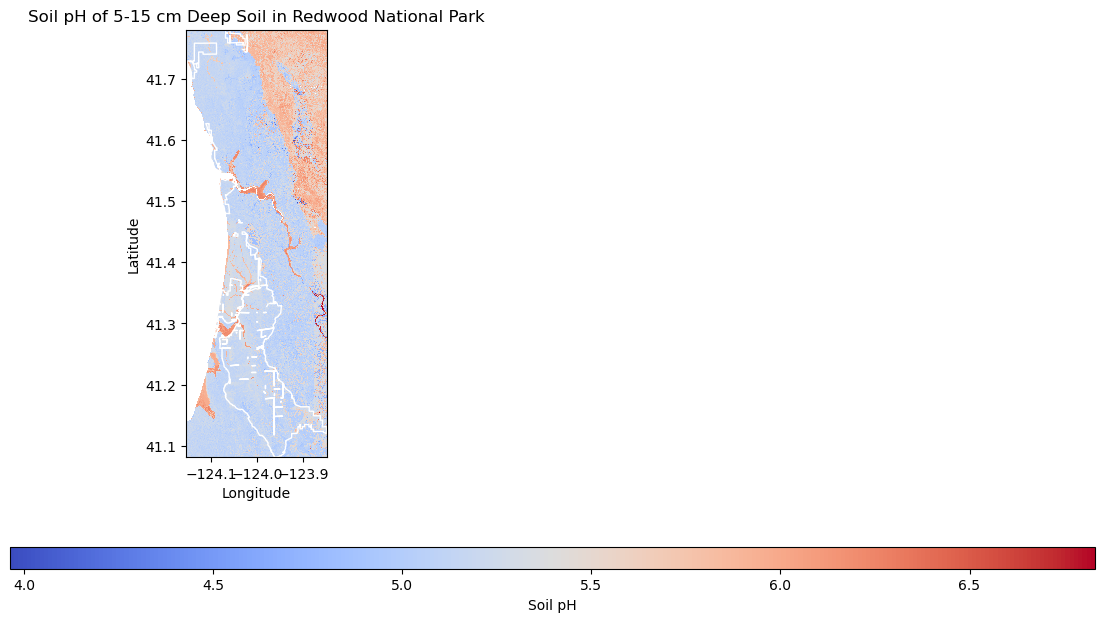

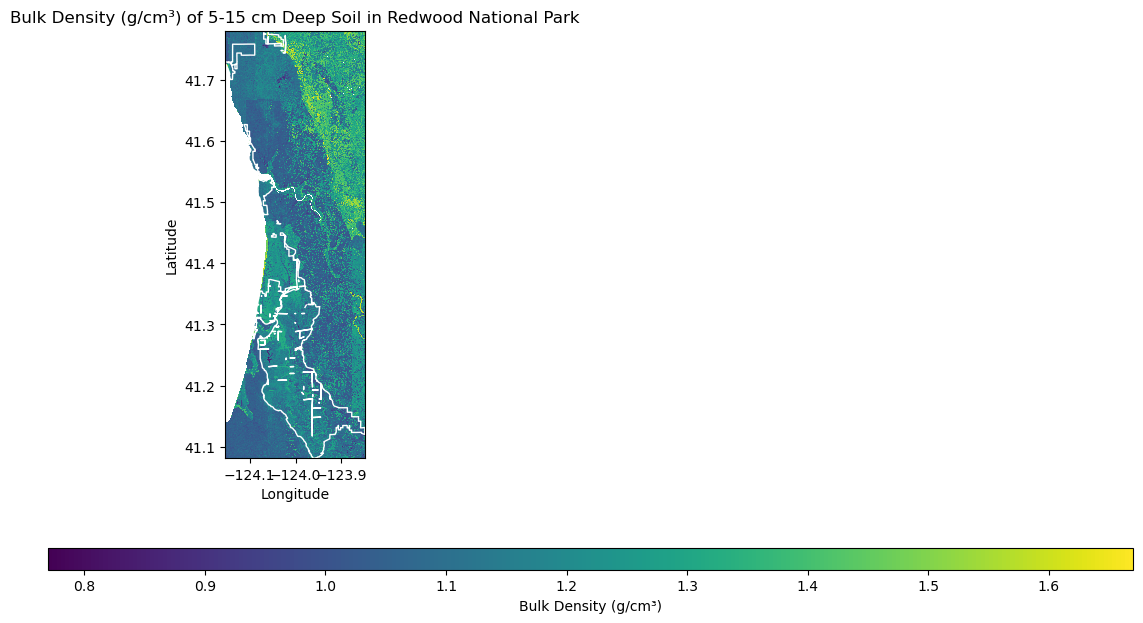

In [38]:
# Create label variables to be inserted into the plot title and color bar
prop_labels = {'ph': 'Soil pH', 'bd': 'Bulk Density (g/cm³)'}

# Configure the color scheme for both plots
prop_cmaps = {'ph': 'coolwarm', 'bd': 'viridis'}

# Create a function that visualizes the soil pH and bulk density data for Redwood National Park:
# Loop over the soil properties
for prop in soil_props:
    # Extract raster for Redwood National Park
    rnp_da = soil_das['rnp'][prop]

    # Configure the color map
    cmap = prop_cmaps[prop]

    # Set minimum and maximum for the color scale
    vmin = float(rnp_da.min())
    vmax = float(rnp_da.max())

    # Create the gridspec layout
    gs = gridspec.GridSpec(2, 2, height_ratios=[20, 1], hspace=0.4)

    # Specify the figure size
    fig = plt.figure(figsize=(14, 7))

    # Create subplot for the raster map
    ax1 = fig.add_subplot(gs[0, 0])

    # Create a dedicated axes object for the horizontal color bar
    cax = fig.add_subplot(gs[1, :])

    # Plot the raster without the built-in color bar
    rnp_plot = rnp_da.plot(
        ax=ax1,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False  # Disable the automatic color bar
    )

    # Reproject the GeoDataFrame to match the raster's CRS
    rnp_gdf_rp = rnp_gdf_refined.to_crs(rnp_da.rio.crs)

    # Plot the reprojected boundaries on top of the raster
    rnp_gdf_rp.plot(ax=ax1, facecolor='none', edgecolor='white', linewidth=1)

    # Set axes limits to the extent of the park boundaries
    xmin, ymin, xmax, ymax = rnp_gdf_rp.total_bounds
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add axes labels for longitude and latitude
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

    # Set the title with the property label
    ax1.set_title(f'{prop_labels[prop]} of 5-15 cm Deep Soil in Redwood National Park')

    # Add a horizontal color bar using the dedicated axes
    plt.colorbar(rnp_plot, cax=cax, orientation='horizontal', label=prop_labels[prop])

    # Display the plot
    plt.show()

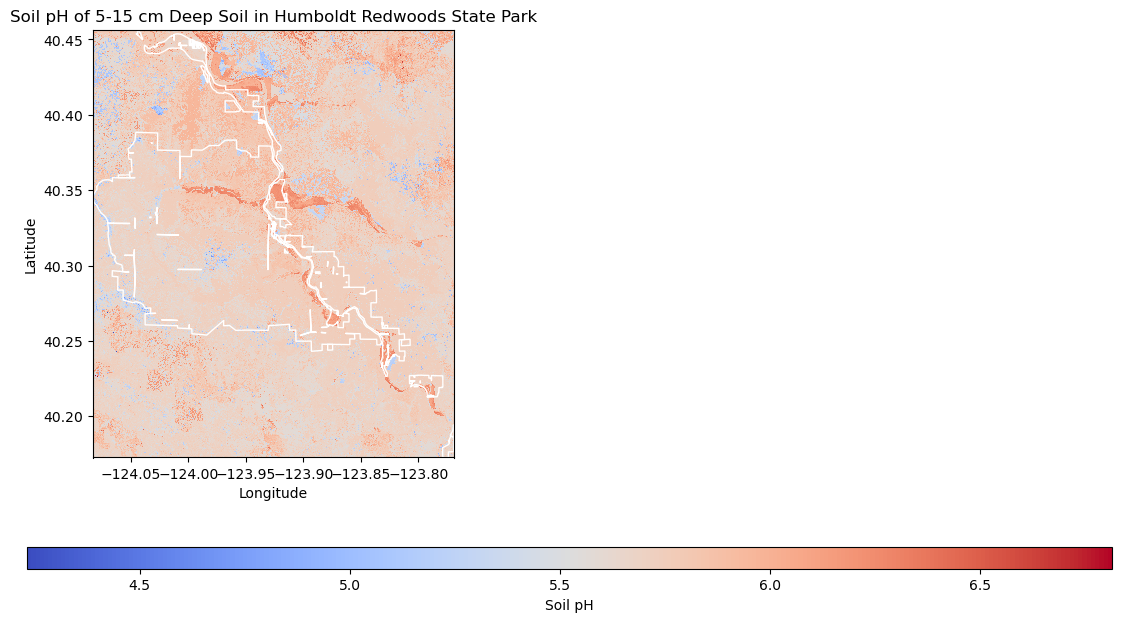

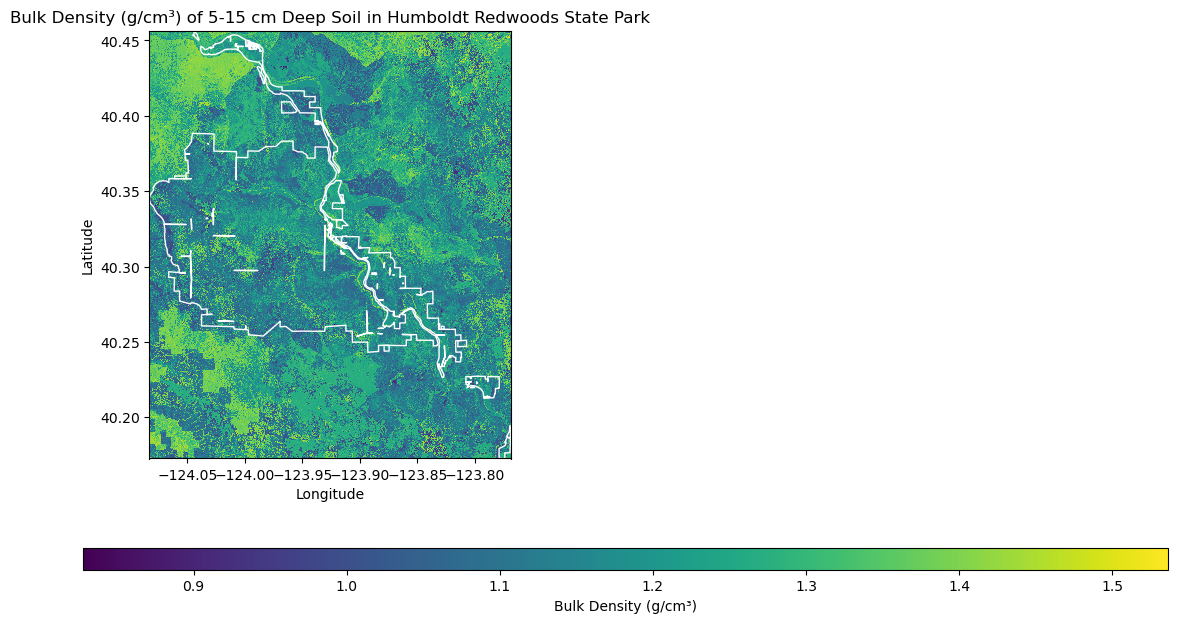

In [39]:
# Create label variables to be inserted into the plot title and color bar
prop_labels = {'ph': 'Soil pH', 'bd': 'Bulk Density (g/cm³)'}

# Configure the color scheme for both plots
prop_cmaps = {'ph': 'coolwarm', 'bd': 'viridis'}

# Create a function that visualizes the soil pH and bulk density data for Humboldt Redwoods State Park:
# Loop over the soil properties
for prop in soil_props:
    # Extract raster for Humboldt Redwoods State
    hrsp_da = soil_das['hrsp'][prop]

    # Configure the color map for the site
    cmap = prop_cmaps[prop]

    # Set minimum and maximum for the color scale
    vmin = float(hrsp_da.min())
    vmax = float(hrsp_da.max())

    # Specify the figure size
    fig = plt.figure(figsize=(14, 7))

    # Create the gridspec layout
    gs = gridspec.GridSpec(2, 2, height_ratios=[20, 1], hspace=0.4)

    # Create a subplot for the raster map
    ax1 = fig.add_subplot(gs[0, 0])

    # Create a dedicated axes object for the horizontal color bar
    cax = fig.add_subplot(gs[1, :])

    # Plot the raster without the built-in color bar
    hrsp_plot = hrsp_da.plot(
        ax=ax1,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False  # Disable the automatic color bar
    )

    # Reproject the GeoDataFrame to match the raster's CRS
    hrsp_gdf_rp = hrsp_gdf_refined.to_crs(hrsp_da.rio.crs)

    # Plot the reprojected boundaries on top of the raster
    hrsp_gdf_rp.plot(ax=ax1, facecolor='none', edgecolor='white', linewidth=1)

    # Set axes limits to the extent of the park boundaries
    xmin, ymin, xmax, ymax = hrsp_gdf_rp.total_bounds
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add axes labels for longitude and latitude
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

    # Set the title with the property label
    ax1.set_title(f'{prop_labels[prop]} of 5-15 cm Deep Soil in Humboldt Redwoods State Park')

    # Add a horizontal color bar using the dedicated axes
    plt.colorbar(hrsp_plot, cax=cax, orientation='horizontal', label=prop_labels[prop])

    # Display the plot
    plt.show()

### Step 2b: Topographic data

Depending on your species habitat needs/environmental parameters, you might be interested in elevation, slope, and/or aspect. You can access reliable elevation data from the [SRTM
dataset](https://www.earthdata.nasa.gov/data/instruments/srtm),
available through the [earthaccess
API](https://earthaccess.readthedocs.io/en/latest/quick-start/). Once you have elevation data, you can calculate slope and aspect.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download SRTM elevation data for a particular location and
calculate any additional topographic variables you need such as slope or
aspect.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include topographic parameters that will help you
to answer your scientific question.</p></div></div>

> **Warning**
>
> Be careful when computing the slope from elevation that the units of
> elevation match the projection units (e.g. meters and meters, not
> meters and degrees). You will need to project the SRTM data to
> complete this calculation correctly.

In [40]:
# Create a directory for the topography data
topography_dir = os.path.join(data_dir, "topography_datasets")
os.makedirs(topography_dir, exist_ok=True)

In [41]:
# Login to NASA Earth Access
earthaccess.login()

INFO:You're now authenticated with NASA Earthdata Login
INFO:Using token with expiration date 04/18/2026


In [42]:
# Access the SRTM data using the keyword "SRTM DEM"
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")

# Print the accessed datasets
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

INFO:Datasets found: 50


ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_NC NASADEM Merged DEM Global 1 arc second nc V001
S

In [43]:
# Create a function that can download SRTM elevation data and derive slopes and aspect rasters for a site:
def topography_data(site_name, site_gdf, topography_dir):
    """""
    Variables:
    site_name: An abbreviation for the site name
    site_gdf: The site boundary GeoDataFrame
    topography_dir: A directory to store downloaded topography data
    """
    # Create a new directory that joins the topography directory and the site name
    site_topography_dir = os.path.join(topography_dir, site_name)
    os.makedirs(site_topography_dir, exist_ok=True)
    # Set the SRTM pattern
    srtm_pattern = os.path.join(site_topography_dir, "*.hgt.zip")
    # Establish the buffer boundary
    buffer = 0.025
    xmin, ymin, xmax, ymax = tuple(site_gdf.total_bounds)
    bounds_buffer = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

    # Proceed with the download if the globbed pattern is not already present
    if not glob(srtm_pattern):
        srtm_search = earthaccess.search_data(
            short_name='SRTMGL3',
            bounding_box=bounds_buffer
        )
        earthaccess.download(srtm_search, site_topography_dir)
    
    # Generate a list of data arrays
    da_list = []
    # Open and merge tiles
    for srtm_path in glob(srtm_pattern):
        tile_da = rxr.open_rasterio(srtm_path, mask_and_scale=True).squeeze()
        da_list.append(tile_da.rio.clip_box(*bounds_buffer))
    # Define the topography data array
    elevation_da = rxrm.merge_arrays(da_list)
    # Aspect the raster
    aspect_da = xrspatial.aspect(elevation_da)
    # Reproject the elevation data array
    elevation_da_rp = elevation_da.rio.reproject('EPSG:5070')
    # Derive the slope from the dataset
    slope_da = xrspatial.slope(elevation_da_rp).rio.reproject('EPSG:4326')

    # Return the data arrays for the elevation, slope, and aspect
    return {'elevation': elevation_da, 'slope': slope_da, 'aspect': aspect_da}

In [44]:
# Create an empty dictionary
topography_das = {}

# Loop over the sites dictionary
# Call "topography_data"
for site_name, gdf in sites.items():
    topography_das[site_name] = topography_data(site_name, gdf, topography_dir)

In [46]:
# List the topography data arrays
topography_das

{'rnp': {'elevation': <xarray.DataArray (y: 900, x: 427)> Size: 2MB
  array([[ 14.,  11.,  12., ..., 782., 798., 807.],
         [ 10.,  10.,  11., ..., 818., 835., 851.],
         [ 11.,   9.,  10., ..., 838., 855., 855.],
         ...,
         [  0.,   0.,   0., ..., 431., 452., 470.],
         [  0.,   0.,   0., ..., 378., 407., 438.],
         [  0.,   0.,   0., ..., 334., 359., 387.]],
        shape=(900, 427), dtype=float32)
  Coordinates:
    * y            (y) float64 7kB 41.8 41.8 41.8 41.8 ... 41.06 41.06 41.06 41.06
    * x            (x) float64 3kB -124.2 -124.2 -124.2 ... -123.8 -123.8 -123.8
      band         int64 8B 1
      spatial_ref  int64 8B 0
  Attributes:
      AREA_OR_POINT:  Point
      units:          m
      _FillValue:     nan,
  'slope': <xarray.DataArray 'slope' (y: 934, x: 957)> Size: 4MB
  array([[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, 

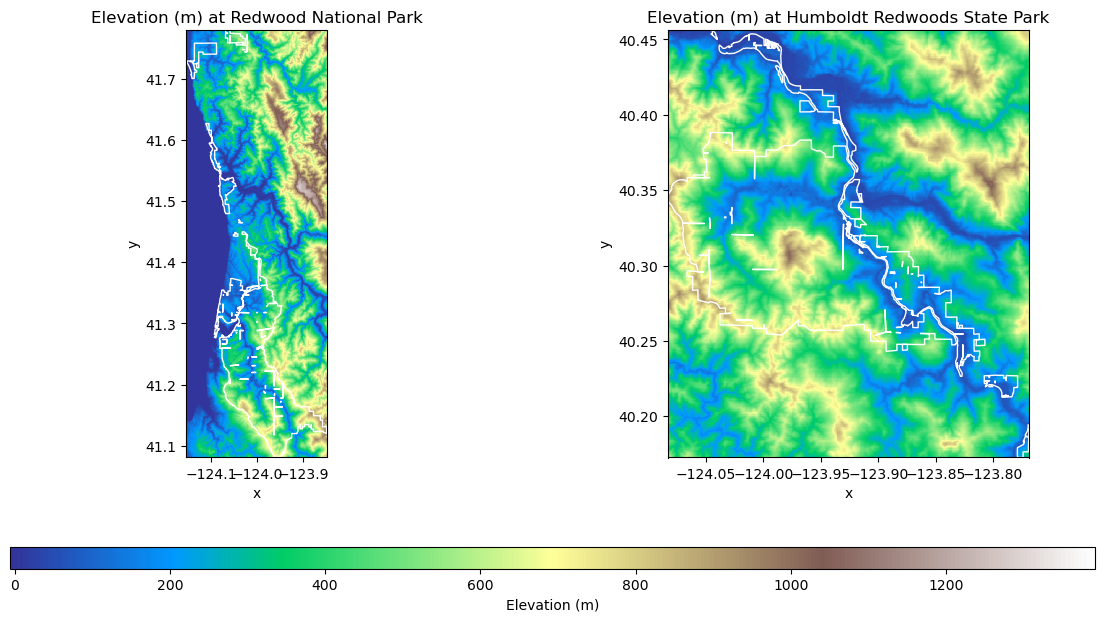

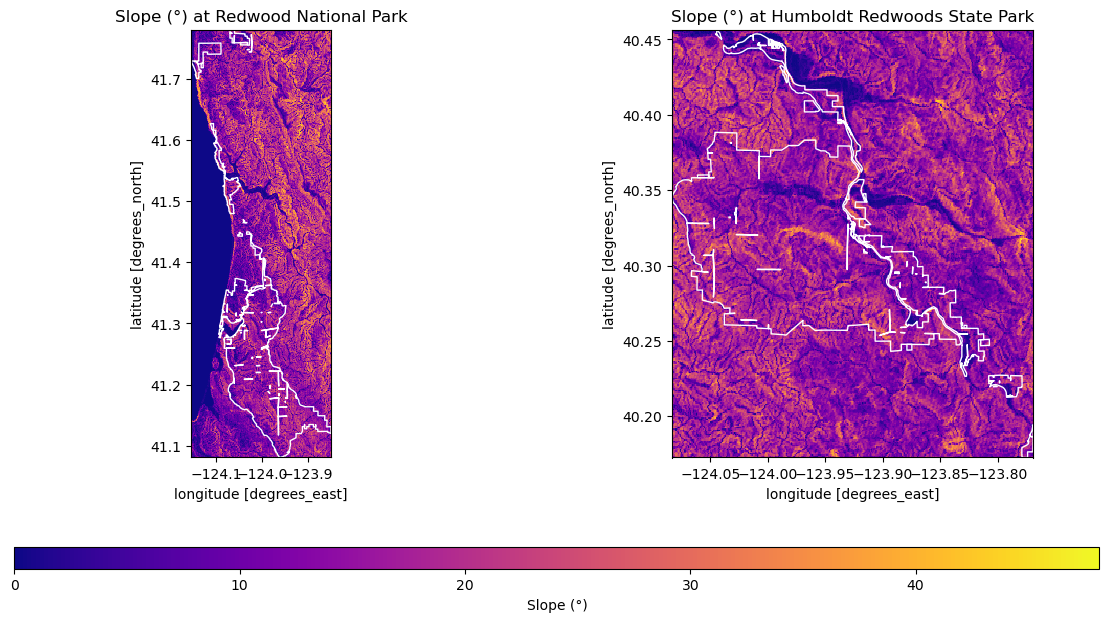

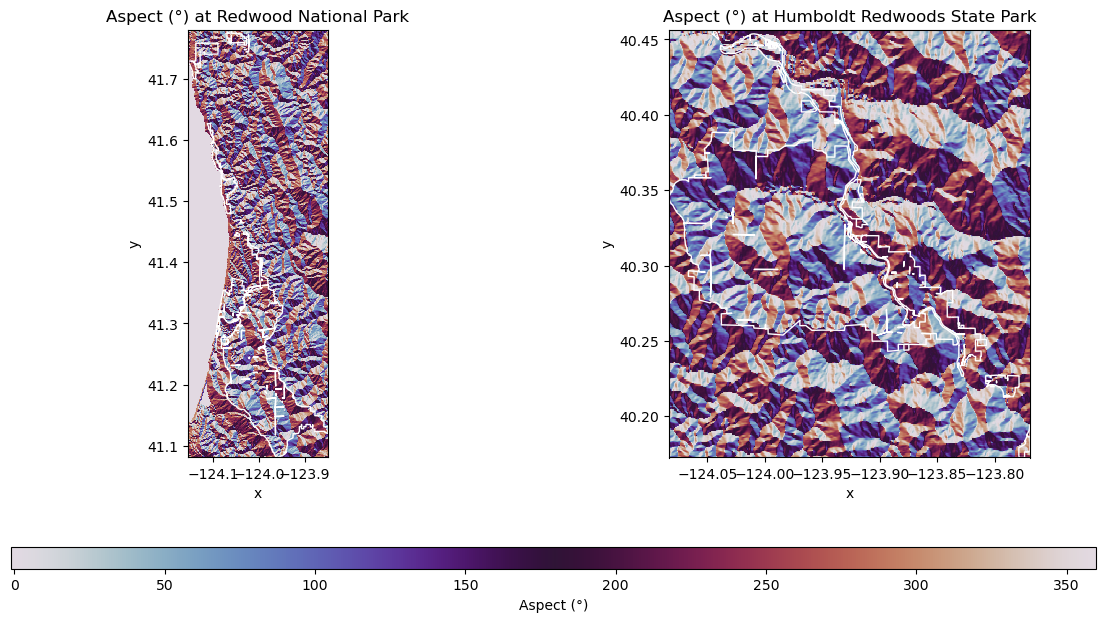

In [45]:
# Add labels for the elevation, slope, and aspect
topography_labels = {
   'elevation': 'Elevation (m)',
    'slope': 'Slope (°)',
    'aspect': 'Aspect (°)'
}

# Color code the labels
topography_cmaps = {
    'elevation': 'terrain',
    'slope': 'plasma',
    'aspect': 'twilight'
}

# Create a function to plot the elevations, slopes, and aspects of RNP and HRSP:
for topography_var in topography_labels:
    rnp_da = topography_das['rnp'][topography_var]
    hrsp_da = topography_das['hrsp'][topography_var]

    # Configure the color map for both sites
    cmap = topography_cmaps[topography_var]

    # Set minimum and maximum for the color scale
    vmin = min(float(rnp_da.min()), float(hrsp_da.min()))
    vmax = max(float(rnp_da.max()), float(hrsp_da.max()))

    # Specify the size of the figures
    fig = plt.figure(figsize=(14, 7))

     # Create the gridspec layout
    gs = gridspec.GridSpec(2, 2, height_ratios=[20, 1], hspace=0.4)

    # Set the axes
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[1, :])

    # Plot the elevation, slope, and aspect at Redwood National Park
    # Set the axis to axis 1 for the Redwood National Park plot
    rnp_da.plot(ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    # Reproject the GeoDataFrame to match the raster's CRS
    rnp_gdf_rp = rnp_gdf_refined.to_crs(rnp_da.rio.crs)
    # Plot the reprojected boundaries on top of the raster
    rnp_gdf_rp.plot(ax=ax1, facecolor='none', edgecolor='white', linewidth=1)
    # Set axes limits to the extent of the park boundaries
    xmin, ymin, xmax, ymax = rnp_gdf_rp.total_bounds
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)
    # Set the title
    ax1.set_title(f'{topography_labels[topography_var]} at Redwood National Park')

    # Plot the elevation, slope, and aspect at Humboldt Redwoods State Park
    # Set the axis to axis 2 for the Humboldt Redwoods State Park plot
    img = hrsp_da.plot(ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    # Reproject the GeoDataFrame to match the raster's CRS
    hrsp_gdf_rp = hrsp_gdf_refined.to_crs(hrsp_da.rio.crs)
    # Plot the reprojected boundaries on top of the raster
    hrsp_gdf_rp.plot(ax=ax2, facecolor='none', edgecolor='white', linewidth=1)
    # Set axes limits to the extent of the park boundaries
    xmin, ymin, xmax, ymax = hrsp_gdf_rp.total_bounds
    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(ymin, ymax)
    # Set the title
    ax2.set_title(f'{topography_labels[topography_var]} at Humboldt Redwoods State Park')

    # Set the color bar
    fig.colorbar(img, cax=cax, orientation='horizontal', label=topography_labels[topography_var])

    # Map the plots
    plt.show()

### Step 2c: Climate model data

You can use MACAv2 data for historical and future climate data. Be sure
to compare at least two 30-year time periods (e.g. historical vs. 10
years in the future) for at least four of the CMIP models. Overall, you
should be downloading at least 8 climate rasters for each of your sites,
for a total of 16. **You will *need* to use loops and/or functions to do
this cleanly!**.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download MACAv2 data for a particular climate model, emissions
scenario, spatial domain, and time frame. Then, use loops to download
and organize the 16+ rasters you will need to complete this section. The
<a
href="http://thredds.northwestknowledge.net:8080/thredds/reacch_climate_CMIP5_macav2_catalog2.html">MACAv2
dataset is accessible from their Thredds server</a>. Include an
arrangement of sites, models, emissions scenarios, and time periods that
will help you to answer your scientific question.</p></div></div>

In [47]:
# Create a directory for the climate data
climate_dir = os.path.join(data_dir, 'climate_dir')
os.makedirs(climate_dir, exist_ok=True)

# Define the pattern and print it
climate_pattern = os.path.join(climate_dir, ".nc")
climate_pattern

'C:\\Users\\livth\\earth-analytics\\data\\spring-03-habitat-suitability-climate-change-Livian-Von-Dran\\redwood_habitat_suitability\\climate_dir\\.nc'

In [48]:
# Create a function that will convert Kelvin to Celsius in an xarray data array
def convert_temperature(temp):
    return temp - 273.15

# Create a function that will convert 0-360 longitude values to a -180 to 180 range
"""The longitude values will also be in an xarray data array."""
def convert_longitude(lon):
    return (lon -360) if lon > 180 else lon

In [49]:
# Create a function that produces a date list range from the MACA data
def MACA_date_ranges(start_year, end_year):
    """
    Variables: 
    start_year: The earliest year in the dataset
    end_year: The final year in the dataset
    """
    # Generate a list of date range intervals
    intervals = []
    # Construct historical intervals in 5-year blocks
    intervals += [(y, y + 4) for y in range(1950, 2001, 5)]
    # Add a transitional interval
    intervals.append((2005, 2005))
    # Construct future intervals in 5-year blocks
    intervals += [(y, y + 4) for y in range(2006, 2096, 5)]
    # Construct a final interval
    intervals.append((2096, 2099))
    # Return intervals only in the requested time range
    return [
        f"{s}_{e}"
        for s, e in intervals
        if s <= end_year and e >= start_year # Only keep intervals that overlap with "start_year" and "end_year"
    ]

In [ ]:
# Create a function that processes the MACA data
def process_MACA_data(site_name,
                    site_gdf, 
                    date_ranges, 
                    models,
                    rcp_value,
                    variable_names, 
                    climate_dir):
        
        # Generate a list of results
        maca_results = []

         # Loop over all data range combinations`
        for date_range in date_ranges:
                for model in models:
                        for variable_name in variable_names:
                                maca_path = os.path.join(climate_dir, f'maca_{model}_{site_name}_{variable_name}_{rcp_value}_{date_range}_CONUS_monthly.nc')

                                # Specify the MACA URL
                                maca_url = (
                                        "http://thredds.northwestknowledge.net:8080/thredds/dodsC/"
                                        "MACAV2/"
                                        f"{model}/"
                                        f"macav2metdata_{clim_var}"
                                        f"_{model}_r1i1p1_"
                                        f"{date_range}_"
                                        "CONUS_monthly.nc"
                                
                                # If the path is missing, download the data
                                if not os.path.exists(maca_path):
                                        r = requests.get(maca_url.replace("dodsC", "fileServer"), stream=True)
                                        r.raise_for_status()
                                        with open(maca_path, "wb") as f:
                                                for chunk in r.iter_content(chunk_size=8192):
                                                        f.write(chunk)
                                        print(f"Downloaded MACA data for {site_name} and saved to {maca_path}")
                                else:
                                 print(f"The MACA data for {site_name} already exists at {maca_path}. Skipping the download.")
                                
                                # Define the MACA data array
                                maca_da = xr.open_dataset(maca_url).squeeze()
                                # Reproject the shapefile's CRS to match the raster's CRS
                                site_rp = site_gdf.to_crs(maca_da.rio.crs)
                                # Align the longitude with a -180 to 180 degree scale
                                maca_da = maca_da.assign_coords(
                                        lon= ("lon", [convert_longitude(lon) for lon in maca_da.lon.values]) # "Lon." is shorthand for longitude
                                        )
                                # Define the spatial dimensions
                                maca_da = maca_da.rio.set_spatial_dims(
                                        x_dim="lon", 
                                        y_dim="lat"
                                        )
                                # Clip the dataset to the sites' bounding boxes
                                maca_da_cropped = maca_da.rio.clip_box(*site_rp.total_bounds, allow_one_dimensional_raster=True)
                                # Store the results
                                result = dict(
                                        site_name = site_name,
                                        climate_model = model,
                                        variable_name = variable_name,
                                        data_range = date_range,
                                        da = maca_da_cropped
                                        )
                                # Append the results list
                                maca_results.append(result)

        # Return the results
        return maca_results

In [ ]:
# Create a function that processes the MACA data
def process_MACA_data(site_name,
                    site_gdf, 
                    date_ranges, 
                    models,
                    rcp_value,
                    variable_names, 
                    climate_dir):
        
        # Generate a list of results
        maca_results = []

         # Loop over all data range combinations`
        for date_range in date_ranges:
                for model in models:
                        for variable_name in variable_names:
                                maca_path = os.path.join(climate_dir, f'maca_{model}_{site_name}_{variable_name}_{rcp_value}_{date_range}_CONUS_monthly.nc')

                                # Specify the MACA URL
                                maca_url = (
                                        "http://thredds.northwestknowledge.net:8080/thredds/dodsC/"
                                        "MACAV2/"
                                        f"{model}/"
                                        f"macav2metdata_{clim_var}"
                                        f"_{model}_r1i1p1_"
                                        f"{date_range}_"
                                        "CONUS_monthly.nc"
                                
                                # If the path is missing, download the data
                                if not os.path.exists(maca_path):
                                        r = requests.get(maca_url.replace("dodsC", "fileServer"), stream=True)
                                        r.raise_for_status()
                                        with open(maca_path, "wb") as f:
                                                for chunk in r.iter_content(chunk_size=8192):
                                                        f.write(chunk)
                                        print(f"Downloaded MACA data for {site_name} and saved to {maca_path}")
                                else:
                                 print(f"The MACA data for {site_name} already exists at {maca_path}. Skipping the download.")
                                
                                # Define the MACA data array
                                maca_da = xr.open_dataset(maca_url).squeeze()
                                # Reproject the shapefile's CRS to match the raster's CRS
                                site_rp = site_gdf.to_crs(maca_da.rio.crs)
                                # Align the longitude with a -180 to 180 degree scale
                                maca_da = maca_da.assign_coords(
                                        lon= ("lon", [convert_longitude(lon) for lon in maca_da.lon.values]) # "Lon." is shorthand for longitude
                                        )
                                # Define the spatial dimensions
                                maca_da = maca_da.rio.set_spatial_dims(
                                        x_dim="lon", 
                                        y_dim="lat"
                                        )
                                # Clip the dataset to the sites' bounding boxes
                                maca_da_cropped = maca_da.rio.clip_box(*site_rp.total_bounds, allow_one_dimensional_raster=True)
                                # Store the results
                                result = dict(
                                        site_name = site_name,
                                        climate_model = model,
                                        variable_name = variable_name,
                                        data_range = date_range,
                                        da = maca_da_cropped
                                        )
                                # Append the results list
                                maca_results.append(result)

        # Return the results
        return maca_results

In [ ]:
# Specify the historical and future date ranges and print them
historical_date_range = MACA_date_ranges(1970, 2009) 
future_date_range = MACA_date_ranges(2045, 2075)

# Specify the climate models used
"""Both sites will use the same four climate models."""
rnp_models = ["CNRM-CM5", "HadGEM2-ES", "CCSM4", "MIROC5"]
hrsp_models = ["CNRM-CM5", "HadGEM2-ES", "CCSM4", "MIROC5"]

In [60]:
# Obtain the data arrays:
# For historical precipitation in Redwood National Park
rnp_historical_precipitation = process_MACA_data(
    "rnp",
    rnp_gdf, 
    historical_date_range, 
    rnp_models,
    "historical", 
    ["pr"], 
    climate_dir)

# For future predicted precipitation in Redwood National Park
rnp_future_precipitation = process_MACA_data(
    "rnp",
    rnp_gdf, 
    future_date_range, 
    rnp_models,
    "rcp85", # RCP 8.5 = high emissions climate scenario
    ["pr"], 
    climate_dir)

# For historical precipitation in Humboldt Redwoods State Park
hrsp_historical_precipitation = process_MACA_data(
    "hrsp",
    hrsp_gdf, 
    historical_date_range, 
    hrsp_models,
    "historical", 
    ["pr"], 
    climate_dir)

# For future predicted precipitation in Humboldt Redwoods State Park
hrsp_future_precipitation = process_MACA_data(
    "hrsp",
    hrsp_gdf, 
    future_date_range, 
    hrsp_models,
    "rcp85", 
    ["pr"], 
    climate_dir)

The MACA data for rnp already exists at C:\Users\livth\earth-analytics\data\spring-03-habitat-suitability-climate-change-Livian-Von-Dran\redwood_habitat_suitability\climate_dir\maca_CNRM-CM5_rnp_pr_historical_1970_1974_CONUS_monthly.nc. Skipping the download.


HTTPError: 404 Client Error: Not Found for url: http://thredds.northwestknowledge.net:8080/thredds/fileServer/MACAV2/HadGEM2-ES/macav2metdata_pr_HadGEM2-ES_r1i1p1_historical_1970_1974_CONUS_monthly.nc

**Reflect and respond**: Make sure to include a description of the climate data and how you selected your models. Include a citation of the MACAv2 data.

Your response here:

## STEP 3: Harmonize data
To use all your environmental and climate data layers together, you need to harmonize the different rasters you've downloaded and processed. 

As a first step, make sure that the grids for all the rasters match each other. Check out the <a href="https://corteva.github.io/rioxarray/stable/examples/reproject_match.html#Reproject-Match"><code>ds.rio.reproject_match()</code> method</a> from <code>rioxarray</code>. Make sure to use the data source that has the highest resolution as a template!</p></div></div>

> **Warning**
>
> If you are reprojecting data (as you need to here), the order of
> operations is important! Recall that reprojecting will typically tilt
> your data, leaving narrow sections of the data at the edge blank.
> However, to reproject efficiently it is best for the raster to be as
> small as possible before performing the operation. We recommend the
> following process:
>
>     1. Crop the data, leaving a buffer around the final boundary
>     2. Reproject to match the template grid (this will also crop any leftovers off the image)

In [ ]:
### Align the grids of the different data layers

## STEP 4: Develop a fuzzy logic model

A fuzzy logic model is one that is built on expert knowledge rather than
training data. You may wish to use the
[`scikit-fuzzy`](https://pythonhosted.org/scikit-fuzzy/) library, which
includes many utilities for building this sort of model. In particular,
it contains a number of **membership functions** which can convert your
data into values from 0 to 1 using information such as, for example, the
maximum, minimum, and optimal values for soil pH.

To train a fuzzy logic habitat suitability model:</p>
<pre><code>1. Find the optimal values for your species for each variable you are using (e.g. soil pH, slope, and current annual precipitation). 
2. For each **digital number** in each raster, assign a **continuous** value from 0 to 1 for how close that grid square/pixel is to the optimum range (1 = optimal, 0 = incompatible). 
3. Combine your layers by multiplying them together. This will give you a single suitability number for each grid square.
4. Optionally, you may apply a suitability threshold to make the most suitable areas pop on your map.</code></pre></div></div>

> **Tip**
>
> If you use mathematical operators on a raster in Python, it will
> automatically perform the operation for every number in the raster.
> This type of operation is known as a **vectorized** function. **DO NOT
> DO THIS WITH A LOOP!**. A vectorized function that operates on the
> whole array at once will be much easier and faster.

In [ ]:
### Create fuzzy logic model for habitat suitability

## STEP 5: Present your results
Generate some plots that show your key findings of habitat suitability in your study sites across the different time periods and climate models. Don’t forget to interpret your plots!

In [ ]:
### Create plots

Interpret your plots here: